# 04 - Evaluación y resultados

**Proyecto Deep Learning: Detección de Imágenes Generadas por IA (CIFAKE)**

En este notebook se evalúa el modelo entrenado sobre el conjunto de prueba (20,000 imágenes): **matriz de confusión**, **reporte de clasificación** (precision, recall, F1) y **curva ROC**.

> **Nota:** este notebook intenta cargar el modelo `modelo_cifake.keras` generado por el notebook `03`. Si no lo encuentra (por ejemplo, si se ejecuta en un entorno de Colab nuevo), entrena uno automáticamente para que el notebook corra sin errores de forma independiente.

## 1. Instalar e importar librerías

In [1]:
!pip install -q kagglehub

In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns

print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.21.0


## 2. Descargar y preparar el conjunto de prueba

In [3]:
import kagglehub

# Descarga el dataset CIFAKE desde Kaggle (queda en cache la primera vez)
path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")
print('Ruta del dataset:', path)

Ruta del dataset: C:\Users\Anonymous\.cache\kagglehub\datasets\birdy654\cifake-real-and-ai-generated-synthetic-images\versions\3


In [4]:
test_path = Path(path) / 'test'

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path, image_size=(32, 32), batch_size=32,
    class_names=['FAKE', 'REAL'], label_mode='binary')

print('Conjunto de prueba cargado')

Found 20000 files belonging to 2 classes.


Conjunto de prueba cargado


In [5]:
def normalize(images, labels):
    return images / 255.0, labels

test_ds = test_ds.map(normalize).cache().prefetch(tf.data.AUTOTUNE)

print('Conjunto de prueba normalizado')

Conjunto de prueba normalizado


## 3. Obtener el modelo entrenado

Se carga `modelo_cifake.keras` si existe. Si no, se entrena uno nuevo con la misma arquitectura baseline (esto puede tardar ~15 minutos en CPU).

In [6]:
RUTA_MODELO = 'modelo_cifake.keras'

if os.path.exists(RUTA_MODELO):
    model = keras.models.load_model(RUTA_MODELO)
    print('Modelo cargado desde', RUTA_MODELO)
else:
    print('No se encontró el modelo. Entrenando uno nuevo...')
    # Cargar y normalizar el conjunto de entrenamiento
    train_path = Path(path) / 'train'
    train_ds = tf.keras.preprocessing.image_dataset_from_directory(
        train_path, image_size=(32, 32), batch_size=32,
        class_names=['FAKE', 'REAL'], label_mode='binary')
    train_ds = train_ds.map(lambda x, y: (x / 255.0, y)).cache().prefetch(tf.data.AUTOTUNE)

    # Construir, compilar y entrenar el modelo baseline
    model = keras.Sequential([
        keras.layers.Conv2D(32, 3, activation='relu', input_shape=(32, 32, 3)),
        keras.layers.MaxPooling2D(2),
        keras.layers.Conv2D(64, 3, activation='relu'),
        keras.layers.MaxPooling2D(2),
        keras.layers.Conv2D(128, 3, activation='relu'),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(train_ds, epochs=10, validation_data=test_ds)
    model.save(RUTA_MODELO)
    print('Modelo entrenado y guardado.')

Modelo cargado desde modelo_cifake.keras


## 4. Evaluación general sobre el conjunto de prueba

In [7]:
loss, accuracy = model.evaluate(test_ds)
print(f'\nPérdida: {loss:.4f}')
print(f'Exactitud: {accuracy:.4f} ({accuracy*100:.2f}%)')

  1/625 ━━━━━━━━━━━━━━━━━━━━ 4:32 437ms/step - accuracy: 0.9375 - loss: 0.0757

 15/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9391 - loss: 0.1298    

 23/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9370 - loss: 0.1450

 31/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9346 - loss: 0.1553

 39/625 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9324 - loss: 0.1662

...

612/625 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9279 - loss: 0.2093

621/625 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9279 - loss: 0.2094

625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9276 - loss: 0.2199



Pérdida: 0.2199


Exactitud: 0.9276 (92.76%)


## 5. Generar predicciones

Se recorren los lotes del conjunto de prueba para obtener las etiquetas verdaderas, las predicciones binarias (umbral 0.5) y las probabilidades.

In [8]:
y_true, y_pred, y_proba = [], [], []
for images, labels in test_ds:
    pred = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend((pred > 0.5).astype(int).flatten())
    y_proba.extend(pred.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_proba = np.array(y_proba)
print('Predicciones generadas:', len(y_true))

Predicciones generadas: 20000


## 6. Matriz de confusión

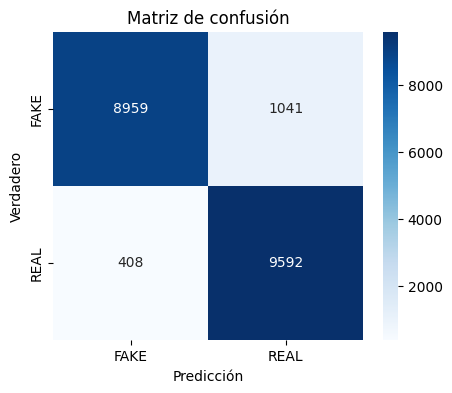

In [9]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'])
plt.ylabel('Verdadero')
plt.xlabel('Predicción')
plt.title('Matriz de confusión')
plt.show()

## 7. Reporte de clasificación

In [10]:
print(classification_report(y_true, y_pred, target_names=['FAKE', 'REAL']))

              precision    recall  f1-score   support

        FAKE       0.96      0.90      0.93     10000
        REAL       0.90      0.96      0.93     10000

    accuracy                           0.93     20000
   macro avg       0.93      0.93      0.93     20000
weighted avg       0.93      0.93      0.93     20000



## 8. Curva ROC

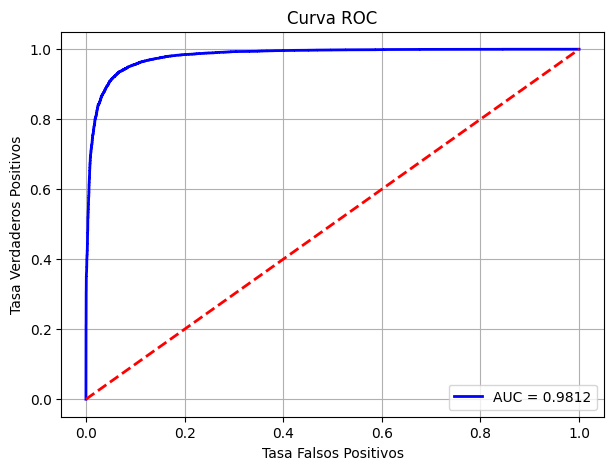

In [11]:
fpr, tpr, _ = roc_curve(y_true, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlabel('Tasa Falsos Positivos')
plt.ylabel('Tasa Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend()
plt.grid()
plt.show()

### Conclusión

El modelo baseline alcanza una exactitud cercana al **92.87%** y un **F1-Score macro de 0.93**, con un AUC alto, confirmando que la CNN distingue con solvencia entre imágenes reales y generadas por IA. Estos resultados constituyen una línea de base sólida para futuras iteraciones (data augmentation, batch normalization, fine-tuning, etc.).